# Visión por Computadora 2025
## Lab 03 


In [2]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import cv2

### Ejercicio 1

In [3]:
def image_rgb_to_bw(image_path, k=1):
  # Conversión de RGB a escala de grises
  image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  
  if image_gray is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}")
  
  # Reescalado (resize) a un tamaño (128k, 64k), (ratio 2:1)
  new_size = (64 * k, 128 * k)
  image_gray = cv2.resize(image_gray, new_size)
  
  # Convertir a numpy array en formato 8 bits o float
  image_array = np.asarray(image_gray, dtype=np.float32 if image_gray.dtype == np.float32 else np.uint8)
  return image_array


Converting image to black and white


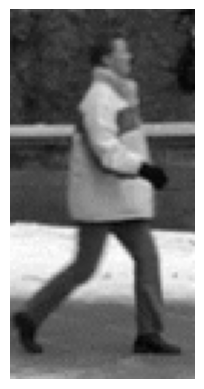

In [4]:

# Read image from input/person.png
image_path = "input/person.png"

# Convert to black and white
image_bw = image_rgb_to_bw(image_path)

print("Converting image to black and white")

# Display the black and white image
plt.imshow(image_bw, cmap='gray')
plt.axis('off')  # Turn off axis
plt.show()


### Ejercicio 2

In [5]:
def compute_gradient(image_path, method='sobel'):
    # Load image

    img = image_rgb_to_bw(image_path)
    
    # Define filters
    if method == 'prewitt':
        kernel_x = np.array([[-1, -1, -1],
                             [ 0,  0,  0],
                             [ 1,  1,  1]])
        
        kernel_y = np.array([[-1,  0,  1],
                             [-1,  0,  1],
                             [-1,  0,  1]])
        
    else:  # Método por defecto: Sobel
        kernel_x = np.array([[-1, -2, -1],
                             [ 0,  0,  0],
                             [ 1,  2,  1]])
    
        kernel_y = np.array([[-1,  0,  1],
                             [-2,  0,  2],
                             [-1,  0,  1]])

    print(f"\n Utilizando el método de {method} \n")

    # Aplicar filtros
    Gx = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel_x)
    Gy = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel_y)
    
    # Calcular magnitud y ángulo del gradiente
    magnitude = np.sqrt(Gx**2 + Gy**2)
    angle = np.arctan2(-Gy, Gx) * (180 / np.pi) % 180  # Convertir a grados y hacer módulo 180
    
    return magnitude, angle


 Utilizando el método de prewitt 



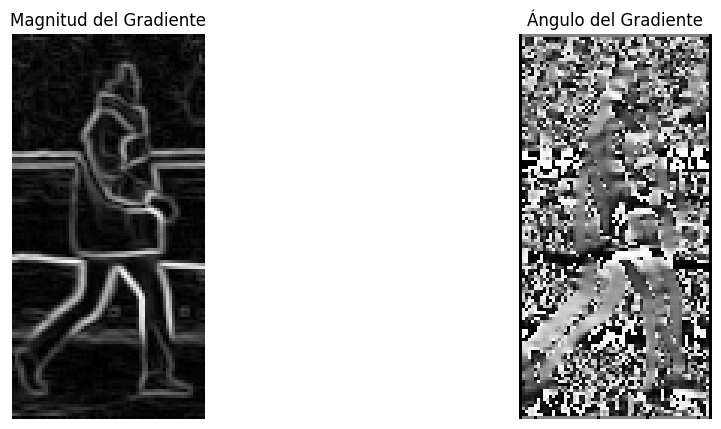

In [6]:
magnitude, angle = compute_gradient(image_path, method='prewitt')

# Mostrar resultados
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitud del Gradiente')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(angle, cmap='gray')
plt.title('Ángulo del Gradiente')
plt.axis('off')

plt.show()




 Utilizando el método de sobel 



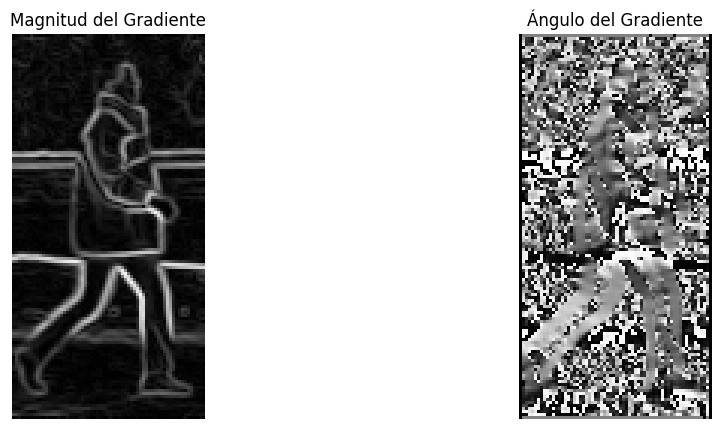

In [7]:
magnitude, angle = compute_gradient(image_path, method='sobel')

# Mostrar resultados
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitud del Gradiente')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(angle, cmap='gray')
plt.title('Ángulo del Gradiente')
plt.axis('off')

plt.show()



### Ejercicio 3

In [8]:
def build_block_stacks(magnitude, angle, block_size):
    stride = block_size // 2
    height, width = magnitude.shape

    magnitude_blocks = []
    angle_blocks = []

    for y in range(0, height - block_size + 1, stride):
        for x in range(0, width - block_size + 1, stride):
            magnitude_block = magnitude[y:y + block_size, x:x + block_size]
            angle_block = angle[y:y + block_size, x:x + block_size]
            magnitude_blocks.append(magnitude_block)
            angle_blocks.append(angle_block)

    magnitude_stack = np.array(magnitude_blocks)
    angle_stack = np.array(angle_blocks)

    M = (height - block_size) // stride + 1
    N = (width - block_size) // stride + 1

    print(f"Shape of magnitude stack: {magnitude_stack.shape}")
    print(f"Shape of angle stack: {angle_stack.shape}")
    print(f"M: {M}, N: {N}")

    return magnitude_stack, angle_stack


In [9]:
magnitude, angle = compute_gradient(image_path)
block_size = 8  # Example block size, should be a multiple of 4
magnitude_stack, angle_stack = build_block_stacks(magnitude, angle, block_size)


 Utilizando el método de sobel 

Shape of magnitude stack: (465, 8, 8)
Shape of angle stack: (465, 8, 8)
M: 31, N: 15


### Ejercicio 4

In [10]:
import numpy as np

def compute_hog(magnitude_stack, angle_stack, n_bins=9):
    """
    Computes the Histogram of Oriented Gradients (HOG) for a stack of image blocks.

    Args:
        magnitude_stack (numpy.ndarray): Stack of magnitude blocks (MN x block_size x block_size).
        angle_stack (numpy.ndarray): Stack of angle blocks (MN x block_size x block_size).
        n_bins (int): Number of bins in the histogram (default is 9).

    Returns:
        numpy.ndarray: Array of HOG features for each block (MN x n_bins).
    """
    histograms = []
    bin_width = 180 / n_bins
    epsilon = 1e-6  # Small constant to avoid division by zero

    for i in range(magnitude_stack.shape[0]):
        magnitude_block = magnitude_stack[i]
        angle_block = angle_stack[i]
        block_histogram = np.zeros(n_bins)

        for y in range(magnitude_block.shape[0]):
            for x in range(magnitude_block.shape[1]):
                magnitude = magnitude_block[y, x]
                angle = angle_block[y, x]

                float_bin_index = angle / bin_width
                bin_index = int(np.floor(float_bin_index))

                # Calculate bin edges
                b1 = bin_index * bin_width
                b2 = (bin_index + 1) * bin_width

                # Calculate weights for bilinear interpolation
                w1 = (b2 - angle) / bin_width
                w2 = (angle - b1) / bin_width

                # Distribute the vote to the two adjacent bins
                block_histogram[bin_index % n_bins] += w1 * magnitude
                block_histogram[(bin_index + 1) % n_bins] += w2 * magnitude

        # Normalize the histogram using the Euclidean norm
        norm = np.sqrt(np.sum(block_histogram**2) + epsilon)
        normalized_histogram = block_histogram / norm
        histograms.append(normalized_histogram)

    return np.array(histograms)



In [20]:
block_size = 8
stride = 8
hog_features = compute_hog(magnitude_stack, angle_stack)
print(f"Shape of HOG features: {hog_features.shape}")

Shape of HOG features: (465, 9)


### Ejercicio 5

In [26]:

def visualize_hog_block_single(hog_block_features, block_size, n_bins=9):
    """
    Converts the HOG histogram of a single block to a visual representation.

    Args:
        hog_block_features (numpy.ndarray): HOG features for a single block (n_bins,).
        block_size (int): Size of the block (e.g., 8).
        n_bins (int): Number of bins in the histogram (default is 9).

    Returns:
        numpy.ndarray: Visual representation of the HOG block (block_size x block_size grayscale image).
    """
    visual_block = np.zeros((block_size, block_size), dtype=np.uint8)
    center_x = block_size // 2
    center_y = block_size // 2
    bin_width = 180 / n_bins
    max_magnitude = np.max(hog_block_features) if hog_block_features.size > 0 else 1.0
    if max_magnitude == 0:
        max_magnitude = 1.0

    for i in range(n_bins):
        magnitude = hog_block_features[i]
        angle_degrees = (i + 0.5) * bin_width
        angle_radians = np.deg2rad(angle_degrees)

        # Scale magnitude to line length
        line_length = int((magnitude / max_magnitude) * (block_size // 2))

        end_x = int(center_x + line_length * np.cos(angle_radians))
        end_y = int(center_y - line_length * np.sin(angle_radians))

        cv2.line(visual_block, (center_x, center_y), (end_x, end_y), int(255 * magnitude / max_magnitude), 1)

    return visual_block

def visualize_hog_direction_image(hog_features, image_height, image_width, block_size, n_bins=9):
    """
    Constructs a direction image by drawing the visual histograms of each block.

    Args:
        hog_features (numpy.ndarray): Array of HOG features for each block (MN x n_bins).
        image_height (int): Height of the original image.
        image_width (int): Width of the original image.
        block_size (int): Size of the block.
        n_bins (int): Number of bins in the histogram.

    Returns:
        numpy.ndarray: Direction image showing the visual HOG of each block.
    """
    stride = block_size // 2
    blocks_rows = image_height // stride
    blocks_cols = image_width // stride
    direction_image = np.zeros((blocks_rows * block_size, blocks_cols * block_size), dtype=np.uint8)

    for i in range(blocks_rows):
        
        if i % 500:
            print(f"Processing row {i} of {blocks_rows}")

        for j in range(blocks_cols):
            block_index = i * blocks_cols + j
            if block_index < hog_features.shape[0]:
                print("Block index:", block_index)
                hog_block = hog_features[block_index]
                visual_block = visualize_hog_block_single(hog_block, block_size, n_bins)
                start_x = j * block_size
                start_y = i * block_size
                direction_image[start_y:start_y + block_size, start_x:start_x + block_size] = visual_block

    return direction_image


In [ ]:
stride = 8
magnitude_stack, angle_stack = build_block_stacks(magnitude, angle, block_size)
hog_features = compute_hog(magnitude_stack, angle_stack)

# Assuming the original image dimensions were used to create the blocks
original_image = image_bw

if original_image is not None:
    image_height, image_width = original_image.shape[:2]
    direction_image = visualize_hog_direction_image(hog_features, image_height, image_width, block_size)


else:
    print("Could not load the image to get its dimensions.")


Shape of magnitude stack: (465, 8, 8)
Shape of angle stack: (465, 8, 8)
M: 31, N: 15
Block index: 0
Block index: 1
Block index: 2
Block index: 3
Block index: 4
Block index: 5
Block index: 6
Block index: 7
Block index: 8
Block index: 9
Block index: 10
Block index: 11
Block index: 12
Block index: 13
Block index: 14
Block index: 15
Processing row 1 of 32
Block index: 16
Block index: 17
Block index: 18
Block index: 19
Block index: 20
Block index: 21
Block index: 22
Block index: 23
Block index: 24
Block index: 25
Block index: 26
Block index: 27
Block index: 28
Block index: 29
Block index: 30
Block index: 31
Processing row 2 of 32
Block index: 32
Block index: 33
Block index: 34
Block index: 35
Block index: 36
Block index: 37
Block index: 38
Block index: 39
Block index: 40
Block index: 41
Block index: 42
Block index: 43
Block index: 44
Block index: 45
Block index: 46
Block index: 47
Processing row 3 of 32
Block index: 48
Block index: 49
Block index: 50
Block index: 51
Block index: 52
Block in

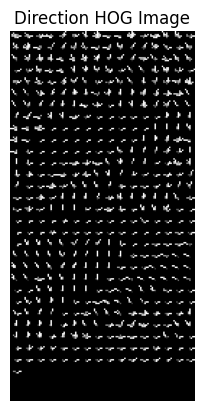

In [29]:

plt.imshow(direction_image, cmap='gray') # You can change 'gray' to other colormaps

# Turn off axis labels and ticks (optional)
plt.axis('off')

# Show the image
plt.title("Direction HOG Image")
plt.show()